In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import math
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
import itertools
import evi_functions as evi_func
import matplotlib.dates as mdates
import warnings
from pathlib import Path
from datetime import datetime
import descri_function as des_fun
import scipy.stats as stats

# Read data

In [9]:
#df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_with_MEM_26_03_2026.parquet')
df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_06_05_2026_with_MEM_ears.parquet')

In [10]:
df.columns

Index(['co_ibge', 'epiweek', 'year', 'year_week', 'week', 'atend_ivas',
       'atend_totais', 'mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01', 'sinal_ears_atend'],
      dtype='object')

In [11]:
#df = pd.read_parquet("/opt/storage/raw/aesop/visualization/ensamble_modelling/aesop_26_03_2026_with_MEM_EVI.parquet")
#df = df[['co_uf', 'nm_uf', 'nm_municipio', 'co_ibge', 'epiyear', 'epiweek',
#       'year_week', 'atend_totais', 'atend_ivas',
#       'mem_surge_01_correct_with_consec', 'warning_final_mem_surge_01',
#       'EWS_ISF_atend_ivas','EWS_LOF_atend_ivas','EWS_OCSVM_atend_ivas',
#       'EWS_COPOD_atend_ivas', 'EWS_Rt_atend_ivas']]

In [12]:
df.co_ibge.nunique()

5365

In [13]:
folder = Path("/opt/storage/raw/aesop/visualization/ensamble_modelling/evi_par/")

evi_par = pd.concat(
    [pd.read_parquet(f) for f in folder.glob("*.parquet")],
    ignore_index=True
)


In [14]:
evi_par = evi_par.assign(co_ibge = evi_par.co_ibge.astype(int),
                                   m = evi_par.m.astype(int))

In [15]:
print('Mean of m with 95% CI', des_fun.mean_confidence_interval2(
   evi_par.m, confidence=0.95
))

Mean of m with 95% CI (4.62, 4.54, 4.69)


In [16]:
print('Mean of m with 95% CI', des_fun.mean_confidence_interval2(
   evi_par.c, confidence=0.95
))

Mean of m with 95% CI (0.19, 0.18, 0.2)


In [17]:
#evi_par.m.quantile(0.75)

# Run evi with optimised parameters for all city

In [18]:
evi_par_dict = evi_par.set_index("co_ibge")[["m","c"]].to_dict("index")

lst_dfs = []

for code in df.co_ibge.unique():

    set_muni = df[df.co_ibge == code].copy()

    pars = evi_par_dict.get(code)

    if pars is None:
        m_, c_ = 5, 0.2
    else:
        m_, c_ = pars["m"], pars["c"]

    # --- run model ---
    dtf = evi_func.func(m_, set_muni.atend_ivas.to_numpy(), 2, 8, c_)

    set_muni = set_muni.reset_index(drop=True)
    set_muni = set_muni.assign(
        evi_t1_t=dtf["evi_t1_t"],
        ind=dtf["ind"]
    )

    # --- clean infinities ---
    finite_vals = set_muni.loc[np.isfinite(set_muni["evi_t1_t"]), "evi_t1_t"]

    if len(finite_vals) > 0:
        max_value = np.nanmax(finite_vals)
        set_muni["evi_t1_t"].replace([np.inf, -np.inf], max_value, inplace=True)

    set_muni["sinal_evi_ivas"] = set_muni["ind"].astype(int)

    lst_dfs.append(set_muni)


In [19]:
df_final = pd.concat(lst_dfs)

In [20]:
df_final.co_ibge.nunique()

5365

In [21]:
df_final.columns

Index(['co_ibge', 'epiweek', 'year', 'year_week', 'week', 'atend_ivas',
       'atend_totais', 'mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01', 'sinal_ears_atend', 'evi_t1_t', 'ind',
       'sinal_evi_ivas'],
      dtype='object')

In [22]:
df_final = df_final[['co_ibge', 'epiweek', 'year', 'year_week', 'week', 'atend_ivas',
       'atend_totais', 'mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01', 'sinal_ears_atend', 
       'sinal_evi_ivas']]

In [23]:
#df_final = df_final[['co_uf', 'nm_uf', 'nm_municipio', 'co_ibge', 'epiyear', 'epiweek',
#       'year_week', 'atend_totais', 'atend_ivas', 
#      'mem_surge_01_correct_with_consec', 'warning_final_mem_surge_01', 'sinal_evi_ivas',
#    'EWS_ISF_atend_ivas','EWS_LOF_atend_ivas','EWS_OCSVM_atend_ivas',
#       'EWS_COPOD_atend_ivas', 'EWS_Rt_atend_ivas']]


       

In [24]:
df_final[(df_final.year_week >= '2022-42') & (df_final.year_week <= '2025-32')].warning_final_mem_surge_01.sum()#.columns 27429

26411

In [25]:
df_final[(df_final.year_week >= '2022-42') & (df_final.year_week <= '2025-32')].sinal_evi_ivas.sum() #140367

150528

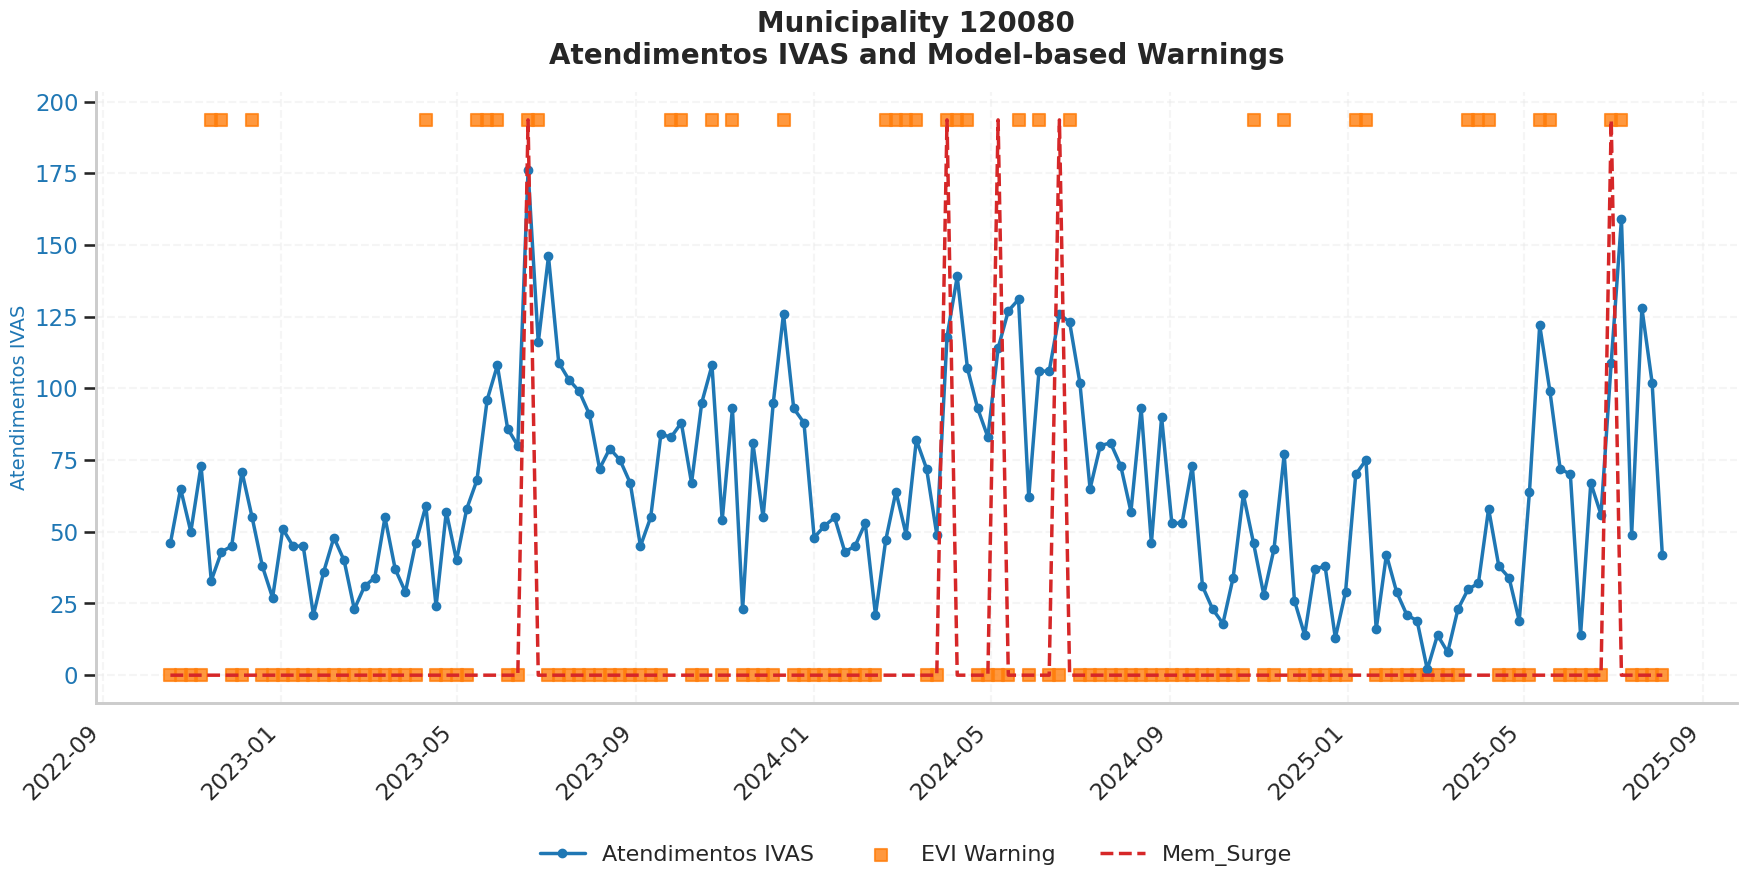

In [26]:
# --- Plot for one municipality ---

code = 120080 	
set_muni = df_final[df_final.co_ibge == code].copy()

set_muni = set_muni[set_muni.year_week >= '2022-42']

muni =  code
plotdf = set_muni.copy()

# --- Convert year_week to datetime (Monday of ISO week) ---
plotdf = set_muni.copy()

plotdf["year"] = plotdf["year_week"].str[:4].astype(int)
plotdf["week"] = plotdf["year_week"].str[-2:].astype(int)

plotdf["date"] = pd.to_datetime(
    plotdf["year"].astype(str) + "-W" + plotdf["week"].astype(str) + "-1",
    format="%G-W%V-%u"
)

plotdf = plotdf.sort_values("date")

# Subtle, clean style
sns.set(style="whitegrid", context="talk")
sns.set_style("whitegrid", {"axes.grid": True, "grid.linestyle": "--", "grid.color": "0.9"})

fig, ax1 = plt.subplots(figsize=(18, 9))

# --- Main ILI line (Atend_ivas) ---
ax1.plot(
    plotdf["date"],
    plotdf["atend_ivas"],
    marker="o",
    color="#1f77b4",
    linewidth=2.5,
    markersize=6,
    label="Atendimentos IVAS"
)
ax1.set_ylabel("Atendimentos IVAS", color="#1f77b4", fontsize=14)
ax1.tick_params(axis="y", labelcolor="#1f77b4")

# --- Model warnings as markers ---
ymax = plotdf["atend_ivas"].max()

warnings = [
    ("sinal_evi_ivas",  1.10, "s", "#ff7f0e", "EVI Warning")
]

for col, mult, mark, colr, label in warnings:
    ax1.scatter(
        plotdf["date"],
        plotdf[col] * ymax * mult,
        marker=mark,
        color=colr,
        s=80,
        alpha=0.8,
        label=label
    )

# --- Secondary axis: memory surge (hidden axis) ---
ax2 = ax1.twinx()
ax2.plot(
    plotdf["date"],
    plotdf["warning_final_mem_surge_01"],#mem_surge_01"],
    color="#d62728",
    linestyle="--",
    linewidth=2.5,
    label="Mem_Surge"
)
# Make secondary axis silent
ax2.set_yticks([])
ax2.set_ylabel("")
ax2.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, labelright=False)
ax2.spines["right"].set_visible(False)

# --- Title and Legend ---
plt.title(
    f"Municipality {muni}\nAtendimentos IVAS and Model-based Warnings",
    fontsize=20, weight="bold", pad=20
)

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2, labels1 + labels2,
    loc="upper center", bbox_to_anchor=(0.5, -0.2),
    ncol=3, frameon=False, fontsize=16
)

# --- Final touches ---
ax1.grid(True, which="major", linestyle="--", alpha=0.4)
ax1.grid(False, which="minor")
fig.tight_layout()
fig.autofmt_xdate(rotation=45)
sns.despine(left=False, right=True)

plt.show()


# Save data

In [27]:
out_dir = Path("/opt/storage/shared/aesop/aesop_shared/ensamble_modelling")


fname = f"aesop_{datetime.now():%d_%m_%Y}_with_MEM_ears_EVI_timing.parquet"

df_final.to_parquet(out_dir / fname)